In [1]:
import pandas as pd
#import gender_guesser.detector as gender
import matplotlib.pyplot as plt
import requests

In [26]:
authors = pd.read_csv('authors_23_03.csv')

/var/folders/qq/hnwvbjqs21xg3srktb91gslr0000gn/T/ipykernel_2312/3369226171.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  authors = pd.read_csv('authors_23_03.csv')


This jupyter notebook takes the original data from the database and assigns a gender to each author. It then also produces some descriptive statistics about the results.

### checking for duplicates

In [3]:
duplicates = authors.groupby('AID').filter(lambda x: (x['LastName'].nunique() > 1))

In [ ]:
if not duplicates.empty:
    print("rows with the same AID but different names:")
    print(duplicates[['AID', 'ForeName', 'LastName']])
    print(f"\nTotal number of such instances: {len(duplicates)}")
else:
    print("Yay")

Yay


### pre-processing

In [ ]:
#remove rows where 'ForeName' has only one, two, three letters
authors = authors[authors['ForeName'].str.len() > 3]

#define a function to extract only the longest full name (ignoring initials)
def longest_full_name(name_string):
    if isinstance(name_string, str):  
        #slit by spaces and filter out single initials
        names = [name for name in name_string.split() if len(name) > 1]
        #if there's at least one valid name, return the longest one
        return max(names, key=len) if names else name_string
    else:
        #if the value isn't a string, return it as-is (e.g., NaN)
        return name_string

#apply the function to the 'ForeName' column
authors['ForeName'] = authors['ForeName'].apply(longest_full_name)

#remove rows where 'ForeName' has only one, two, three letters
authors = authors[authors['ForeName'].str.len() > 3]

print(authors['ForeName'])

207266       Marti
207267     Celeste
207268       Janet
212164     William
212165      Jerome
            ...   
2178186      Arnie
2178187      Ellen
2178188    Richard
2178189    Bernard
2178190       Ajay
Name: ForeName, Length: 1389482, dtype: object


In [7]:
len(authors['ForeName'].unique()) #number of unique names in the dataset

85768

## Genderize.io

In [8]:
api_key = "freebie-43191756-b6af-4d64-afec-e34c223dbe88"

In [ ]:
#guess gender
def batch_get_gender(names, batch_size=10):
    result = {}
    
    valid_names = [name for name in names if pd.notna(name) and name.strip() != '']
    
    for i in range(0, len(valid_names), batch_size):
        batch = valid_names[i:i+batch_size]
        name_params = '&'.join([f'name[]={name}' for name in batch])
        
        try:
            response = requests.get(f'https://api.genderize.io/?name={name_params}&apikey={api_key}')
            data = response.json()
            
            for item in data:
                if 'name' in item and 'gender' in item:
                    result[item['name']] = item['gender'] if item['gender'] else 'unknown'
        except:
            #in case of error, mark all names in the batch as unknown
            for name in batch:
                result[name] = 'unknown'
    
    return result

def apply_batch_gender(df, name_column):
    unique_names = df[name_column].dropna().unique()
    
    gender_dict = batch_get_gender(unique_names)
    
    return df[name_column].map(lambda x: gender_dict.get(x, 'unknown') if pd.notna(x) else 'unknown')

### checking if it works

In [ ]:
#new_df = authors.head(50).copy()

In [ ]:
#new_df

,PMID,DescriptorName_UI,LastName,ForeName,Journal_JournalIssue_PubDate_MedlineDate,Journal_JournalIssue_PubDate_Year
248287,7425110,D001943,Garamendi,Celeste,NaN,1980.0
248288,7425110,D001943,Messerli,Marti,NaN,1980.0
248289,7425110,D001943,Romano,Janet,NaN,1980.0
253804,7512659,D011471,Ahmann,Frederick,NaN,1994.0
253805,7512659,D011471,Catalona,William,NaN,1994.0
253806,7512659,D011471,Dalkin,Bruce,NaN,1994.0
253807,7512659,D011471,DeKernion,Jean,NaN,1994.0
253808,7512659,D011471,Flanigan,Robert,NaN,1994.0
253809,7512659,D011471,Hudson,M'Liss,NaN,1994.0
253810,7512659,D011471,Kavoussi,Louis,NaN,1994.0


In [ ]:
#new_df['Gender'] = apply_batch_gender(new_df, 'ForeName')

In [ ]:
#new_df

,PMID,DescriptorName_UI,LastName,ForeName,Journal_JournalIssue_PubDate_MedlineDate,Journal_JournalIssue_PubDate_Year,Gender
248287,7425110,D001943,Garamendi,Celeste,NaN,1980.0,unknown
248288,7425110,D001943,Messerli,Marti,NaN,1980.0,female
248289,7425110,D001943,Romano,Janet,NaN,1980.0,female
253804,7512659,D011471,Ahmann,Frederick,NaN,1994.0,male
253805,7512659,D011471,Catalona,William,NaN,1994.0,male
253806,7512659,D011471,Dalkin,Bruce,NaN,1994.0,male
253807,7512659,D011471,DeKernion,Jean,NaN,1994.0,female
253808,7512659,D011471,Flanigan,Robert,NaN,1994.0,male
253809,7512659,D011471,Hudson,M'Liss,NaN,1994.0,female
253810,7512659,D011471,Kavoussi,Louis,NaN,1994.0,male


### doing it for all of the data

In [10]:
authors['Gender'] = apply_batch_gender(authors, 'ForeName')

In [11]:
authors

,PMID,DescriptorName_UI,LastName,ForeName,AID,ORCID,Journal_JournalIssue_PubDate_MedlineDate,Journal_JournalIssue_PubDate_Year,Gender
207266,7425110,D001943,Messerli,Marti,1048456,NaN,NaN,1980.0,unknown
207267,7425110,D001943,Garamendi,Celeste,5266862,NaN,NaN,1980.0,female
207268,7425110,D001943,Romano,Janet,1523439,NaN,NaN,1980.0,female
212164,7512659,D011471,Catalona,William,4264591,NaN,NaN,1994.0,male
212165,7512659,D011471,Richie,Jerome,4258456,NaN,NaN,1994.0,male
...,...,...,...,...,...,...,...,...,...
2178186,32702310,D001943,Purushotham,Arnie,1316527,NaN,NaN,2020.0,male
2178187,32702310,D001943,Nolte,Ellen,148517,NaN,NaN,2020.0,unknown
2178188,32702310,D001943,Sullivan,Richard,4379387,NaN,NaN,2020.0,male
2178189,32702310,D001943,Rachet,Bernard,7023995,NaN,NaN,2020.0,male


In [ ]:
authors.to_csv('authors_gendered.csv', index=False) #save

# descriptive statistics

In [21]:
authors = pd.read_csv('authors_gendered.csv')

/var/folders/qq/hnwvbjqs21xg3srktb91gslr0000gn/T/ipykernel_2312/3701441037.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  authors = pd.read_csv('authors_gendered.csv')


In [6]:
#split the df based on each category
unknown_df = authors[authors['Gender'] == 'unknown']
male_df = authors[authors['Gender'] == 'male']
female_df = authors[authors['Gender'] == 'female']

print(f"Unknown: {len(unknown_df['ForeName'])}")
print(f"Male: {len(male_df['ForeName'])}")
print(f"Female: {len(female_df['ForeName'])}")

unknown_df['ForeName'].to_csv("unknowns.csv", index=False)

Unknown: 64206
Male: 241111
Female: 180384


## all authors

In [ ]:
def plot_stacked_bar(df_dict, gender_colors, output_file='StackedBarplotGender.png', text_file='percentages.txt'):

    counts = [len(df['ForeName']) for df in df_dict.values()] #calculate counts
    categories = list(df_dict.keys())

    total_count = sum(counts) 
    percentages = [(count / total_count) * 100 for count in counts] #normalize counts

    #stacked bar
    x = ['Authors'] #to get a single bar
    bottom_value = 0
    colors = [gender_colors[category] for category in categories]

    plt.figure(figsize=(8, 6))
    for percentage, category, color in zip(percentages, categories, colors):
        plt.bar(x, percentage, bottom=bottom_value, label=category.capitalize().replace('_', ' '), color=color)
        bottom_value += percentage

    with open(text_file, 'w') as f:
        f.write('Category Percentages:\n')
        for category, percentage in zip(categories, percentages):
            f.write(f'{category.capitalize().replace("_", " ")}: {percentage:.2f}%\n')

    plt.ylabel('Percentage of Authors', fontsize=12)
    plt.ylim(0, 100)
    plt.legend(title='Categories', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()

    plt.savefig(output_file)
    plt.show()

    return counts


gender_colors = {
    'male': 'darkorchid',
    'female': 'darkorange',
    'unknown': 'darkgray',
}

df_dict_all = {
    'unknown': unknown_df,
    'male': male_df,
    'female': female_df,
}


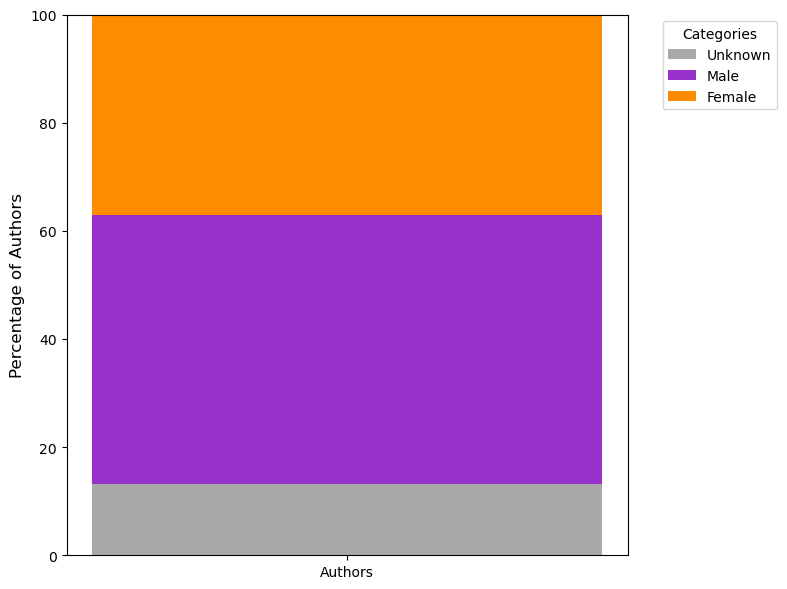

[64206, 241111, 180384]

In [10]:
plot_stacked_bar(df_dict_all, gender_colors, output_file='StackedBarplotGender_all.png', text_file='percentages_all_authors.txt')

## stacked barplot per disease

In [11]:
df_dict_prostate = {
    'unknown': unknown_df[(unknown_df['DescriptorName_UI'] == 'D013736') | (unknown_df['DescriptorName_UI']  == 'D011471')],
    'male': male_df[(male_df['DescriptorName_UI'] == 'D013736') | (male_df['DescriptorName_UI']  == 'D011471')],
    'female': female_df[(female_df['DescriptorName_UI'] == 'D013736') | (female_df['DescriptorName_UI']  == 'D011471')],
}

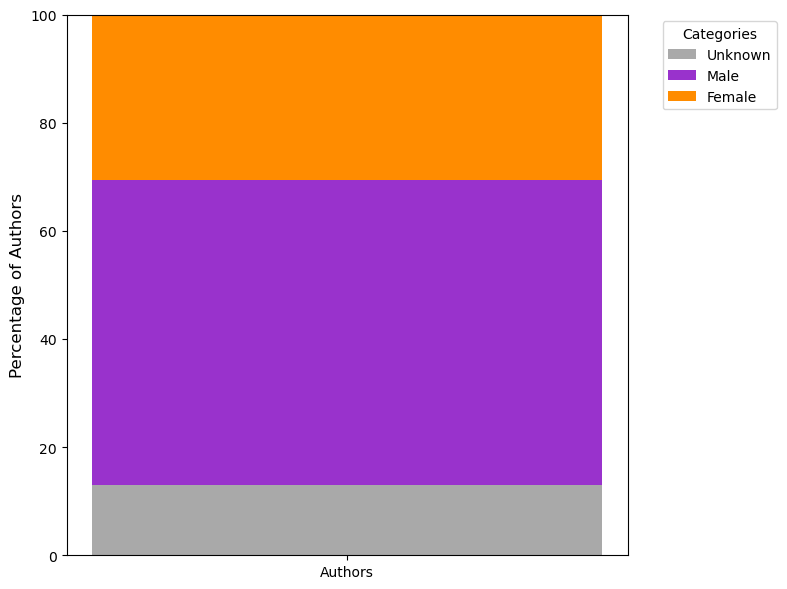

[17684, 76773, 41598]

In [12]:
plot_stacked_bar(df_dict_prostate, gender_colors, output_file='StackedBarplotProstate.png', text_file='percentages_prostate_authors.txt')

In [13]:
df_dict_breast = {
    'unknown': unknown_df[unknown_df['DescriptorName_UI'] == 'D001943'],
    'male': male_df[male_df['DescriptorName_UI'] == 'D001943'],
    'female': female_df[female_df['DescriptorName_UI'] == 'D001943'],
}

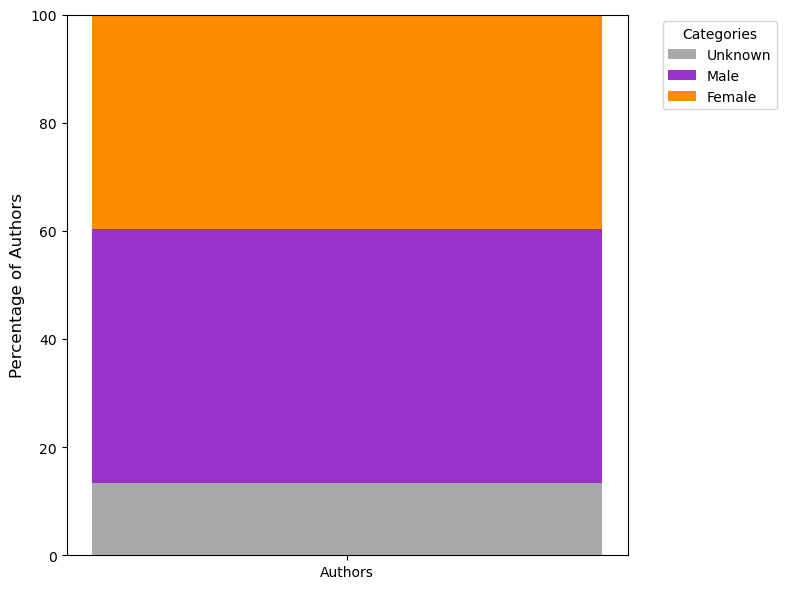

[46522, 164338, 138786]

In [14]:
plot_stacked_bar(df_dict_breast, gender_colors, output_file='StackedBarplotBreast.png', text_file='percentages_breast_authors.txt')

In [15]:
prostate_cancer = authors[(authors['DescriptorName_UI'] == 'D013736') | (authors['DescriptorName_UI']  == 'D011471')]
breast_cancer = authors[authors['DescriptorName_UI'] == 'D001943']

In [16]:
gender_colors = {
    'Male Breast Cancer': 'darkorchid',
    'Female Breast Cancer': 'darkorange',
    'Male Prostate Cancer': 'darkorchid',
    'Female Prostate Cancer': 'darkorange',
    'Total Breast Cancer': 'lightcyan',
    'Total Prostate Cancer': 'lightcyan'
}

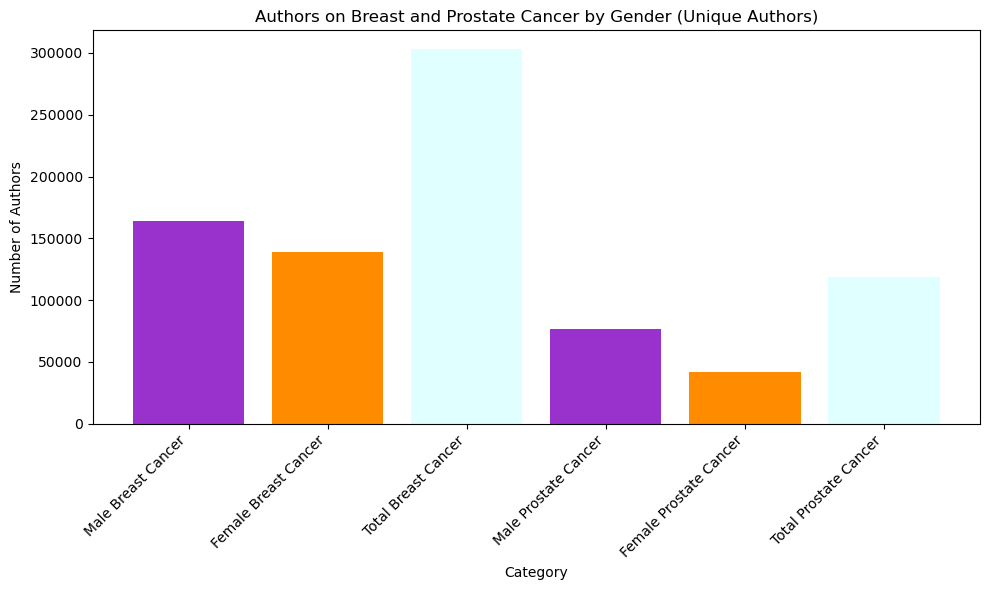

In [17]:
#remove unknowns
prostate_cancer_clean = prostate_cancer[prostate_cancer['Gender'].isin(['male', 'female'])]
breast_cancer_clean = breast_cancer[breast_cancer['Gender'].isin(['male', 'female'])]

unique_male_breast = breast_cancer_clean[breast_cancer_clean['Gender'] == 'male']['AID'].nunique()
unique_female_breast = breast_cancer_clean[breast_cancer_clean['Gender'] == 'female']['AID'].nunique()
total_unique_breast = unique_male_breast + unique_female_breast

unique_male_prostate = prostate_cancer_clean[prostate_cancer_clean['Gender'] == 'male']['AID'].nunique()
unique_female_prostate = prostate_cancer_clean[prostate_cancer_clean['Gender'] == 'female']['AID'].nunique()
total_unique_prostate = unique_male_prostate + unique_female_prostate

#generate categories
categories = ['Male Breast Cancer', 'Female Breast Cancer', 'Total Breast Cancer',
              'Male Prostate Cancer', 'Female Prostate Cancer', 'Total Prostate Cancer']
counts_unique = [unique_male_breast, unique_female_breast, total_unique_breast, unique_male_prostate, unique_female_prostate, total_unique_prostate]
counts_unique

colors = [gender_colors[category] for category in categories]

#plot barchart
plt.figure(figsize=(10, 6))
plt.bar(categories, counts_unique, color=colors)

plt.xlabel('Category')
plt.ylabel('Number of Authors')
plt.title('Authors on Breast and Prostate Cancer by Gender (Unique Authors)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('BarplotGenderperDisease.png')
plt.show()

### relative number of researchers of a psecific gender per field

In [18]:
print(unique_male_breast/total_unique_breast)
print(unique_female_breast/total_unique_breast)
print(unique_male_prostate/total_unique_prostate)
print(unique_female_prostate/total_unique_prostate)

0.5421477679101622
0.45785223208983783
0.6485794662544035
0.35142053374559645
